In [1]:
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
data = pd.read_csv(r"C:\Users\Lenovo\.spyder-py3\food_ingredients_and_allergens (1).csv")

In [5]:
data.head()

,Food Product,Main Ingredient,Sweetener,Fat/Oil,Seasoning,Allergens,Prediction
0,Almond Cookies,Almonds,Sugar,Butter,Flour,"Almonds, Wheat, Dairy",Contains
1,Almond Cookies,Almonds,Sugar,Butter,Flour,"Almonds, Wheat, Dairy",Contains
2,Chicken Noodle Soup,Chicken broth,NaN,NaN,Salt,"Chicken, Wheat, Celery",Contains
3,Chicken Noodle Soup,Chicken broth,NaN,NaN,Salt,"Chicken, Wheat, Celery",Contains
4,Cheddar Cheese,Cheese,NaN,NaN,Salt,Dairy,Contains


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 399 entries, 0 to 398
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Food Product     399 non-null    object
 1   Main Ingredient  399 non-null    object
 2   Sweetener        119 non-null    object
 3   Fat/Oil          341 non-null    object
 4   Seasoning        379 non-null    object
 5   Allergens        251 non-null    object
 6   Prediction       398 non-null    object
dtypes: object(7)
memory usage: 21.9+ KB


In [9]:
data.describe(include='all')

,Food Product,Main Ingredient,Sweetener,Fat/Oil,Seasoning,Allergens,Prediction
count,399,399,119,341,379,251,398
unique,259,101,9,35,185,39,2
top,Stuffed Bell Peppers,Chicken,Sugar,Olive oil,Soy sauce,Dairy,Contains
freq,4,61,92,90,15,83,255


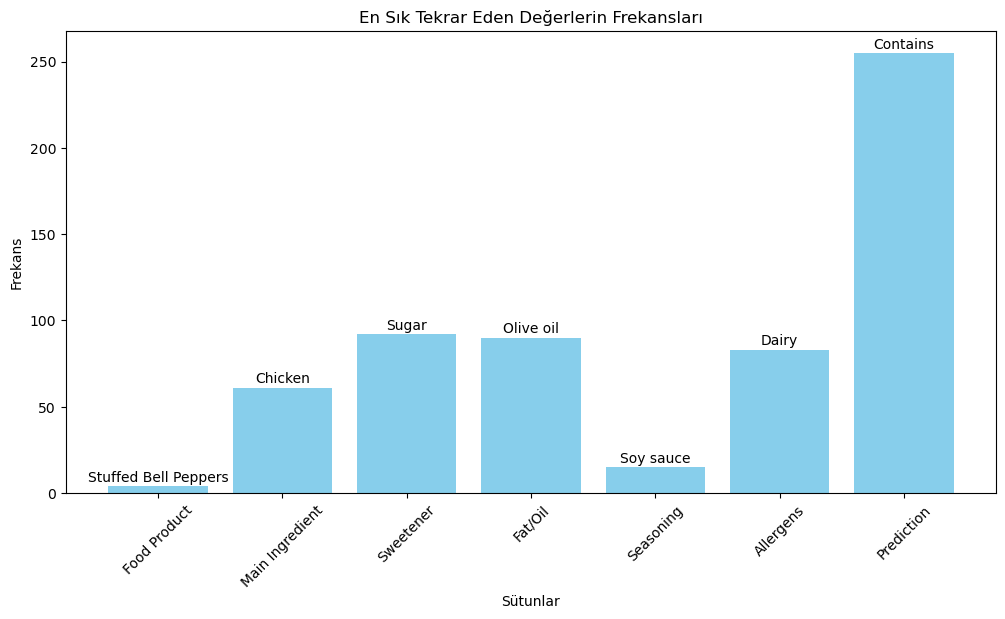

In [11]:
top_values = data.apply(lambda x: x.value_counts().idxmax())
top_frequencies = data.apply(lambda x: x.value_counts().max())

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(top_values.index, top_frequencies, color='skyblue')

for bar, value in zip(bars, top_values):
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 1, value, ha='center', va='bottom')

ax.set_title('En Sık Tekrar Eden Değerlerin Frekansları')
ax.set_ylabel('Frekans')
ax.set_xlabel('Sütunlar')
plt.xticks(rotation=45)
plt.show()

In [13]:
for column in data.select_dtypes(include='object').columns:
    print(data[column].value_counts())


Food Product
Stuffed Bell Peppers    4
Chicken Noodle Soup     4
Chicken Curry           4
Ratatouille             4
Caesar Salad Wrap       4
                       ..
Veggie Burger           1
Vegetable Soup          1
Minestrone Soup         1
Salsa                   1
Hawaiian Pizza          1
Name: count, Length: 259, dtype: int64
Main Ingredient
Chicken             61
Flour               16
Beef                15
Pasta               14
Apples              12
                    ..
Semolina             1
Kidney beans         1
Fermented batter     1
Pork ribs            1
Pecans               1
Name: count, Length: 101, dtype: int64
Sweetener
Sugar           92
Honey           12
Mayonnaise       5
Brown sugar      3
Cocoa butter     2
Marshmallows     2
Rice vinegar     1
Caramel          1
Tamarind         1
Name: count, dtype: int64
Fat/Oil
Olive oil                            90
Butter                               85
Vegetable oil                        43
Ghee               

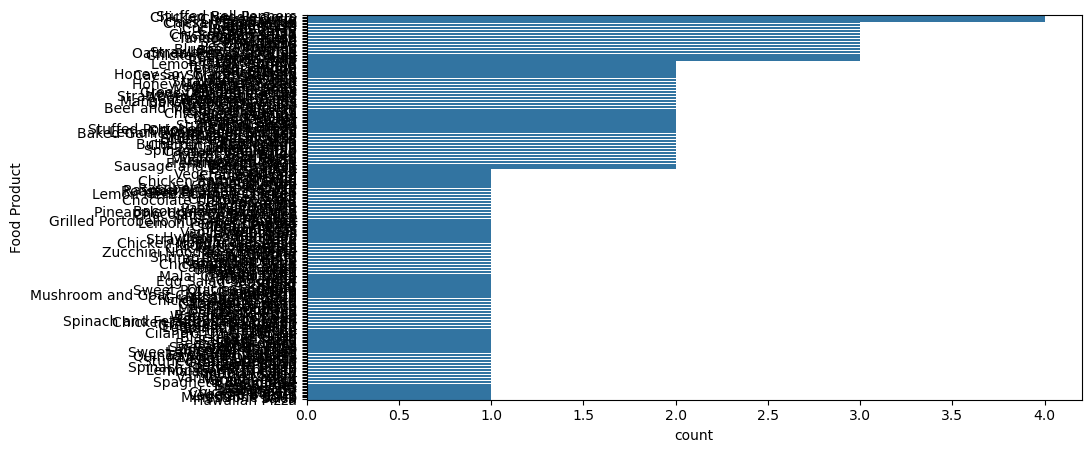

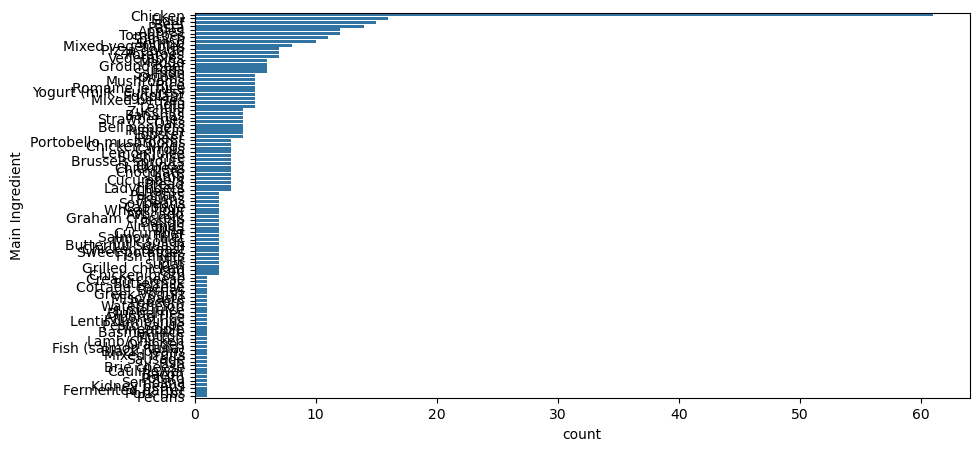

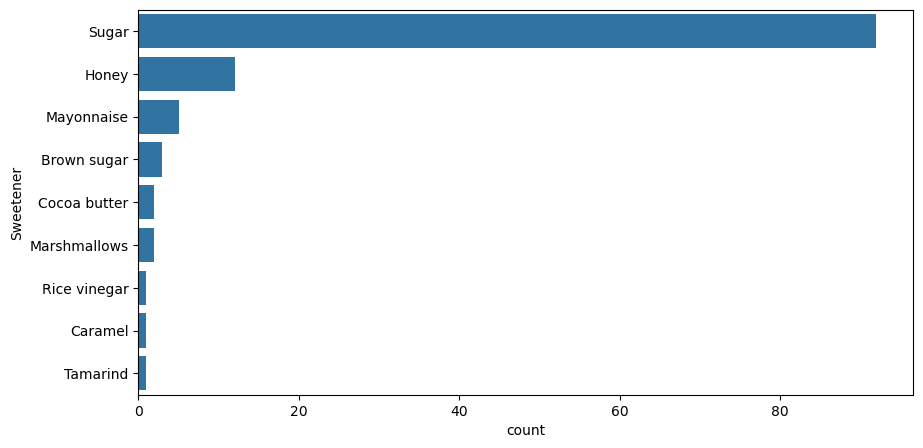

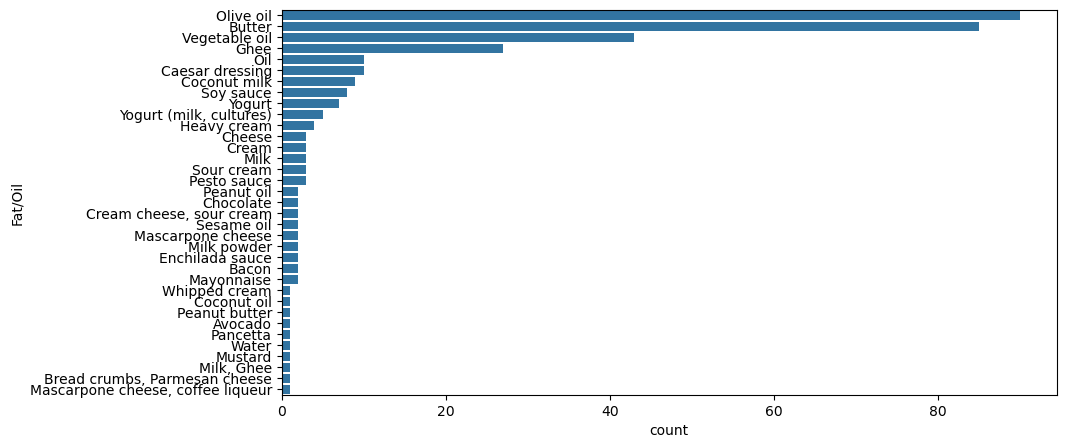

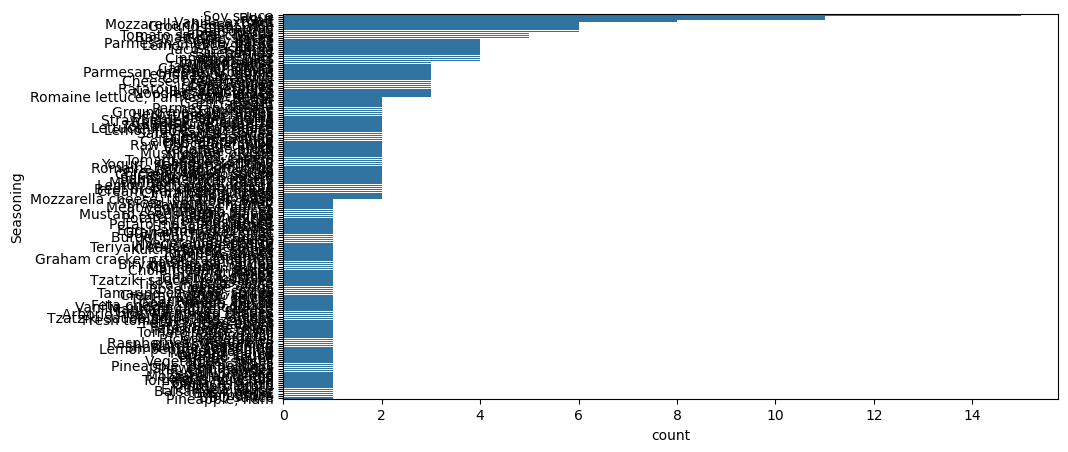

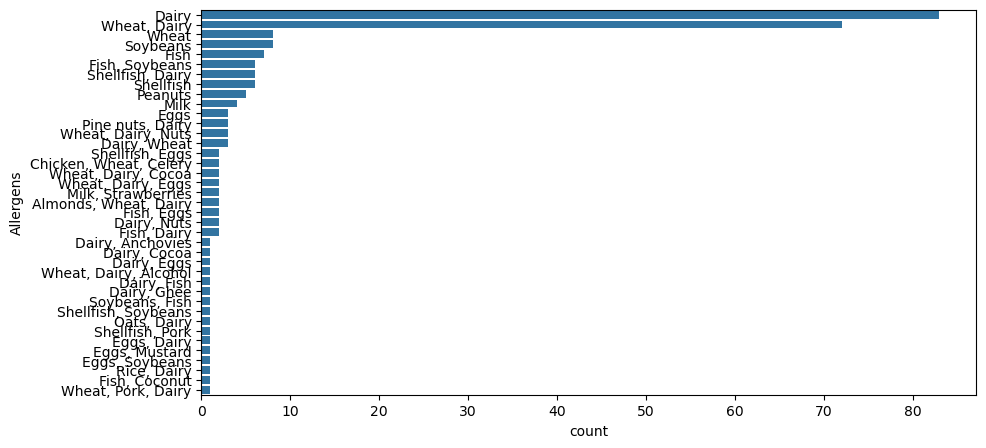

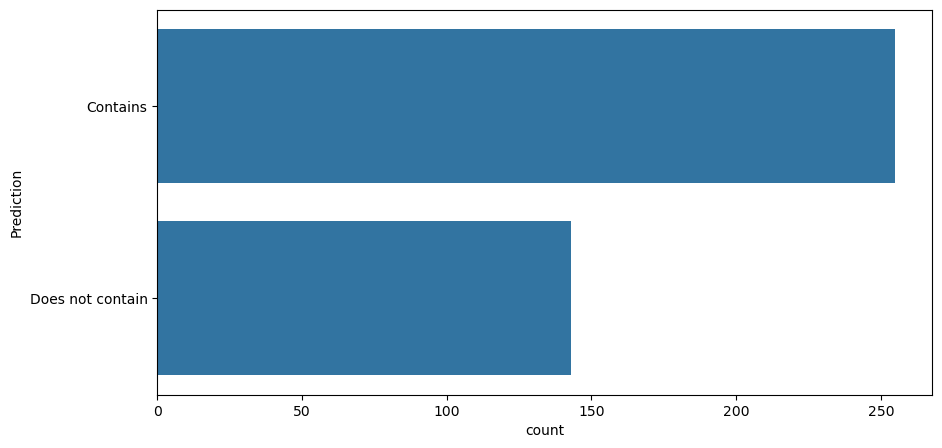

In [15]:
#bar grafikleri
import matplotlib.pyplot as plt
import seaborn as sns

for column in data.select_dtypes(include='object').columns:
    plt.figure(figsize=(10, 5))
    sns.countplot(y=column, data=data, order=data[column].value_counts().index)
    plt.show()


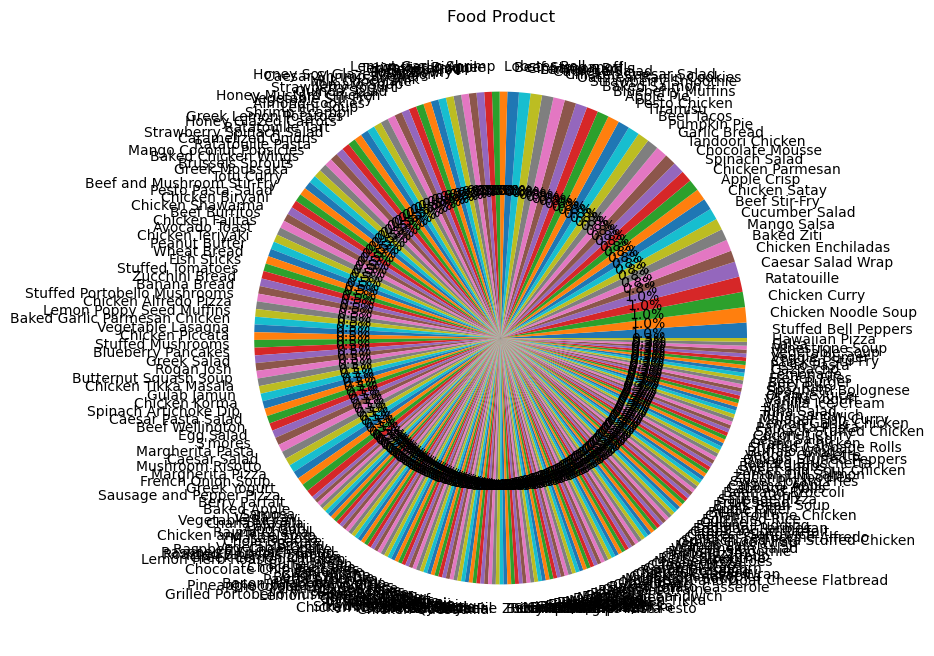

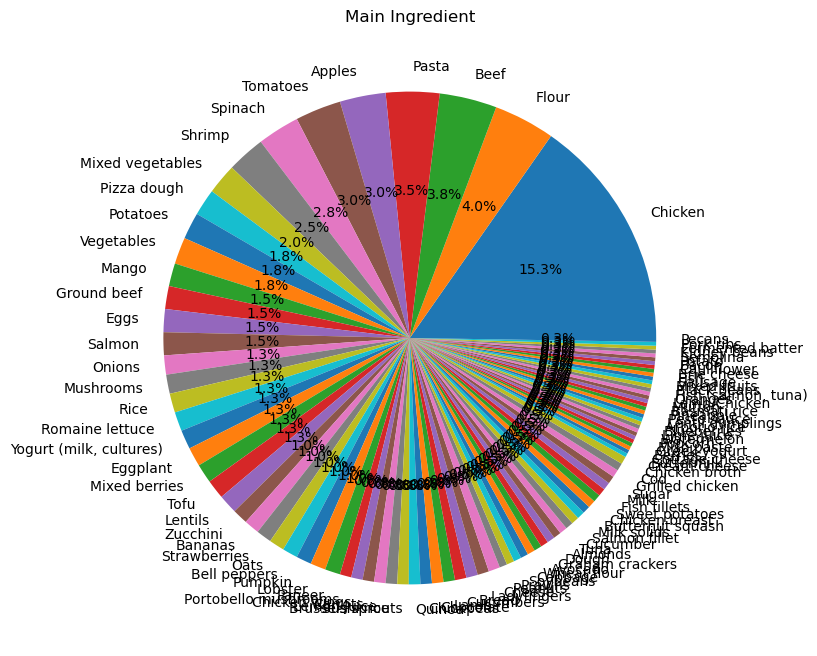

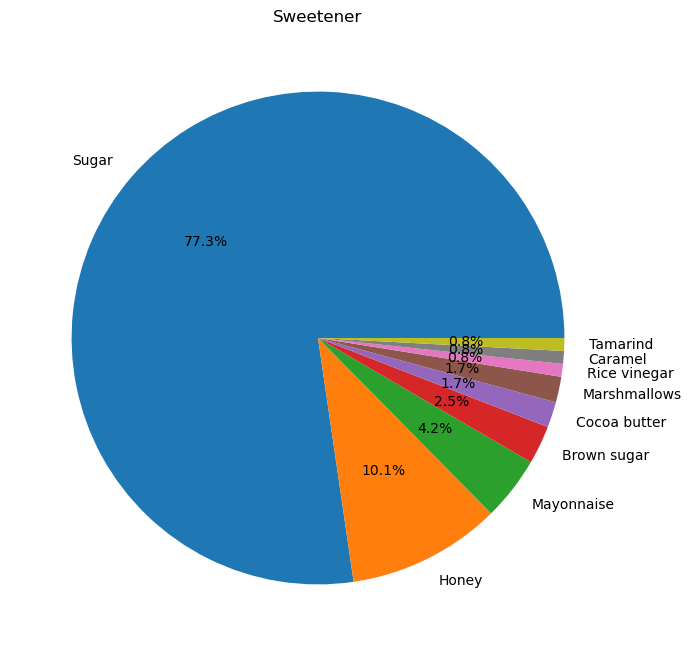

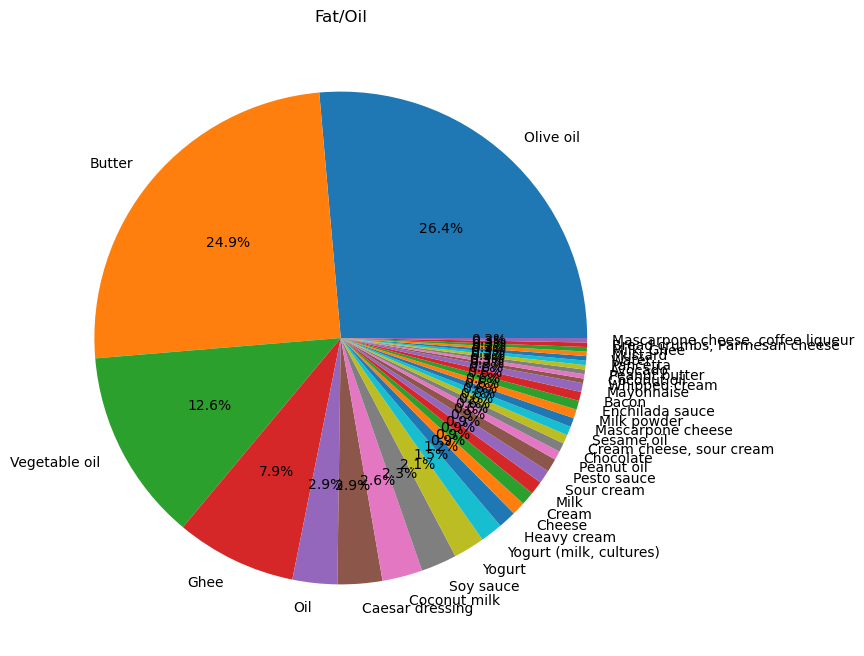

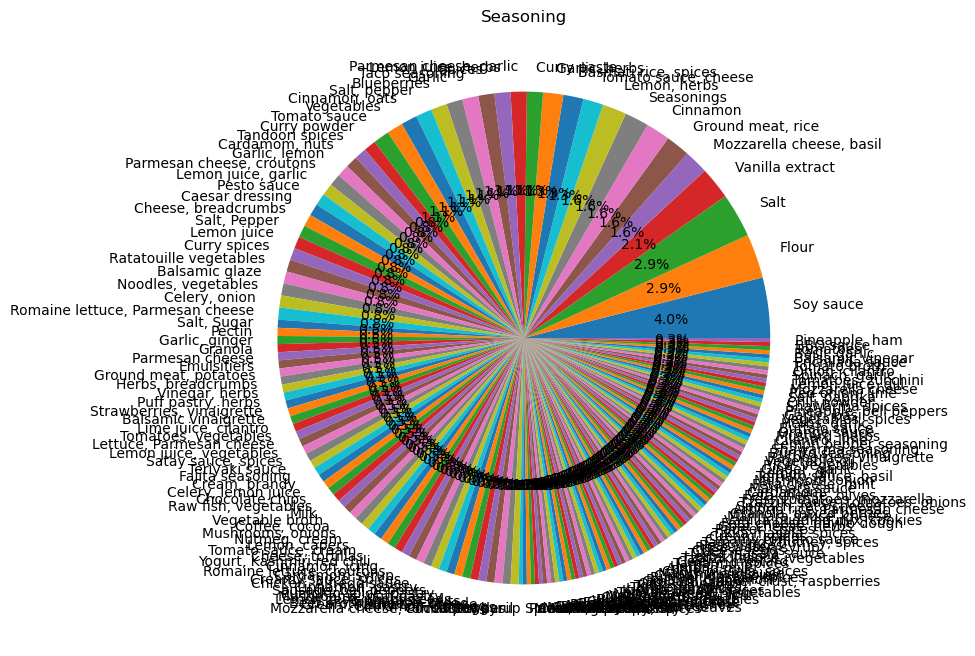

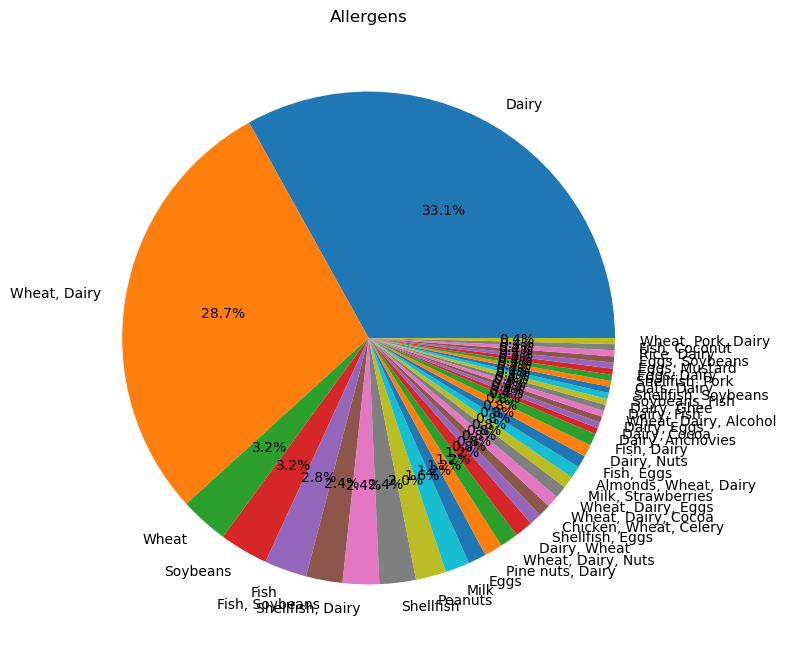

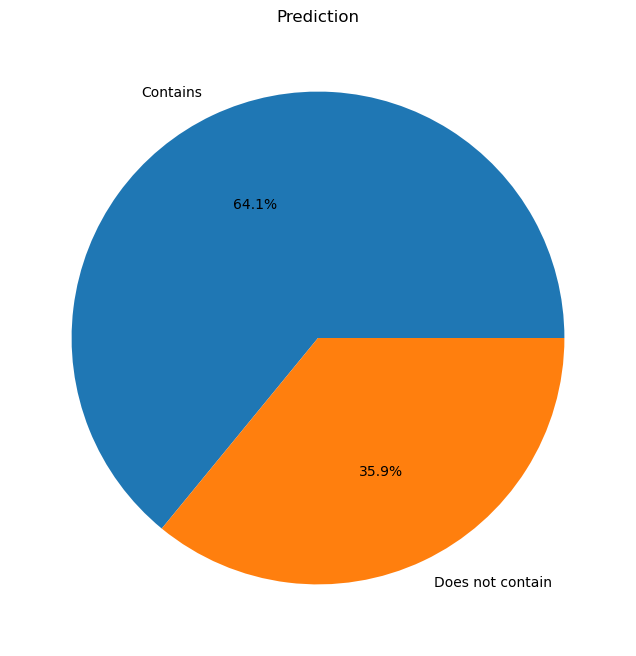

In [17]:
#pie grafikleri
for column in data.select_dtypes(include='object').columns:
    data[column].value_counts().plot.pie(autopct='%1.1f%%', figsize=(8, 8))
    plt.title(column)
    plt.ylabel('')
    plt.show()


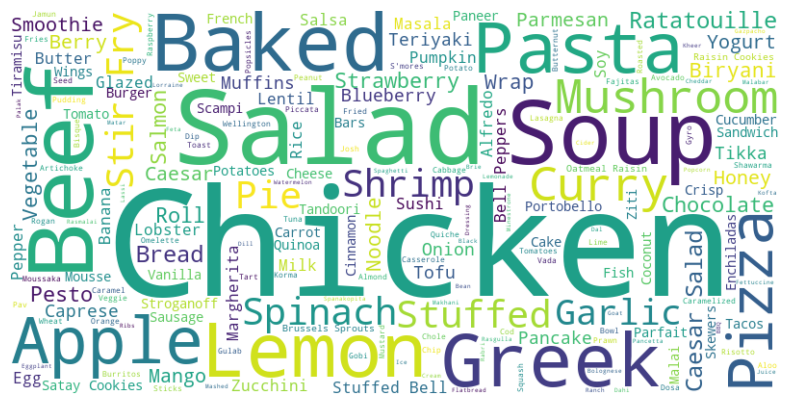

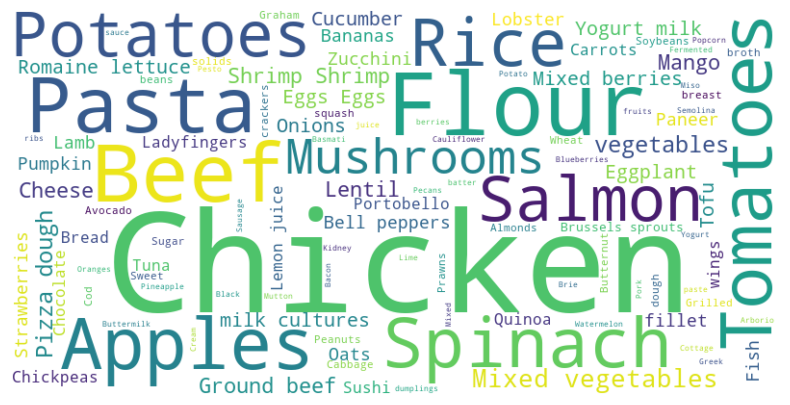

In [19]:
from wordcloud import WordCloud

text = ' '.join(data['Food Product'].astype(str))
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

text = ' '.join(data['Main Ingredient'].astype(str))
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()



## KORELASYON ANALİZİ

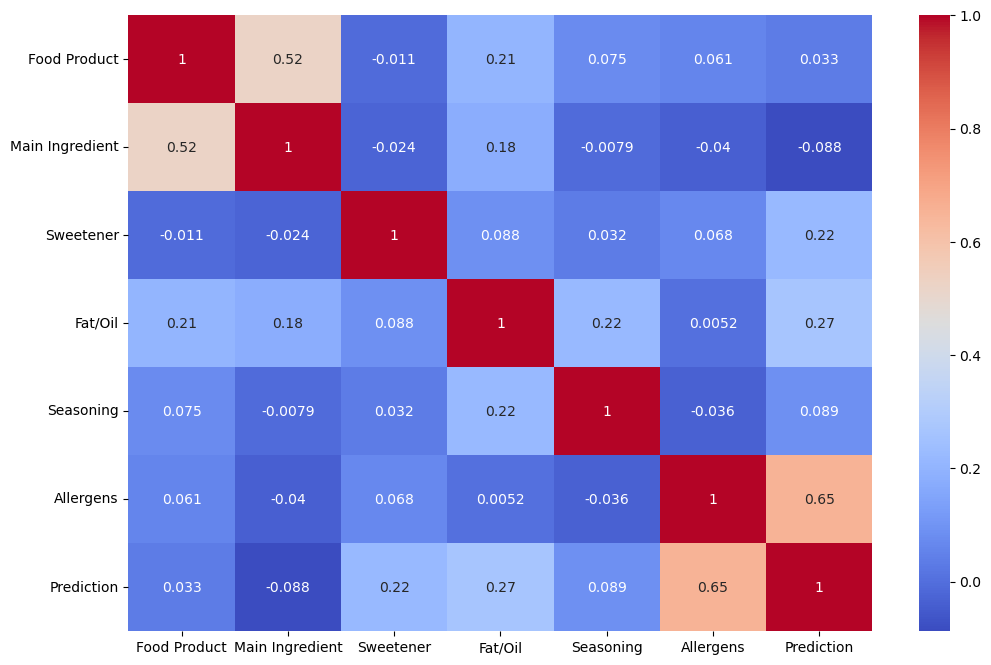

In [21]:
#label encoding ve korelasyon
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
data_encoded = data.apply(lambda col: le.fit_transform(col) if col.dtype == 'object' else col)
correlation_matrix = data_encoded.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.show()


## FREKANS ANALİZİ

In [23]:
for column in data.select_dtypes(include='object').columns:
    print(data[column].value_counts(normalize=True))


Food Product
Stuffed Bell Peppers    0.010025
Chicken Noodle Soup     0.010025
Chicken Curry           0.010025
Ratatouille             0.010025
Caesar Salad Wrap       0.010025
                          ...   
Veggie Burger           0.002506
Vegetable Soup          0.002506
Minestrone Soup         0.002506
Salsa                   0.002506
Hawaiian Pizza          0.002506
Name: proportion, Length: 259, dtype: float64
Main Ingredient
Chicken             0.152882
Flour               0.040100
Beef                0.037594
Pasta               0.035088
Apples              0.030075
                      ...   
Semolina            0.002506
Kidney beans        0.002506
Fermented batter    0.002506
Pork ribs           0.002506
Pecans              0.002506
Name: proportion, Length: 101, dtype: float64
Sweetener
Sugar           0.773109
Honey           0.100840
Mayonnaise      0.042017
Brown sugar     0.025210
Cocoa butter    0.016807
Marshmallows    0.016807
Rice vinegar    0.008403
Caramel     

## BOŞ DEĞERLER

In [25]:
print(data.isnull().sum())

Food Product         0
Main Ingredient      0
Sweetener          280
Fat/Oil             58
Seasoning           20
Allergens          148
Prediction           1
dtype: int64


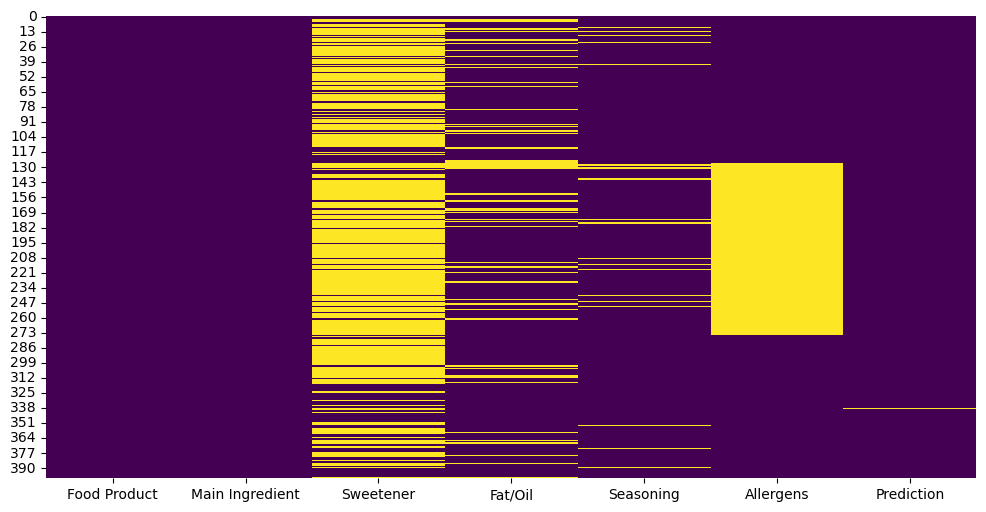

In [64]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6)) #ısı haritaları
sns.heatmap(data.isnull(), cbar=False, cmap='viridis')
plt.show()


In [27]:
import pandas as pd
data = pd.read_csv(r"C:\Users\Lenovo\.spyder-py3\food_ingredients_and_allergens (1).csv")

In [29]:
data.head()


,Food Product,Main Ingredient,Sweetener,Fat/Oil,Seasoning,Allergens,Prediction
0,Almond Cookies,Almonds,Sugar,Butter,Flour,"Almonds, Wheat, Dairy",Contains
1,Almond Cookies,Almonds,Sugar,Butter,Flour,"Almonds, Wheat, Dairy",Contains
2,Chicken Noodle Soup,Chicken broth,NaN,NaN,Salt,"Chicken, Wheat, Celery",Contains
3,Chicken Noodle Soup,Chicken broth,NaN,NaN,Salt,"Chicken, Wheat, Celery",Contains
4,Cheddar Cheese,Cheese,NaN,NaN,Salt,Dairy,Contains


In [31]:
print(data.isnull().sum())



Food Product         0
Main Ingredient      0
Sweetener          280
Fat/Oil             58
Seasoning           20
Allergens          148
Prediction           1
dtype: int64


In [17]:
# Boş değerleri unknown ile doldurdum. (allergens sütununu doldurmadım çünkü kategorik özellikler içerisinde yer almayacak) 
data['Sweetener'] = data['Sweetener'].fillna('unknown')
data['Fat/Oil'] = data['Fat/Oil'].fillna('unknown')
data['Seasoning'] = data['Seasoning'].fillna('unknown')
data['Prediction'] = data['Prediction'].fillna(0)

In [43]:
print(data.isnull().sum())

Food Product         0
Main Ingredient      0
Sweetener            0
Fat/Oil              0
Seasoning            0
Allergens          148
Prediction           0
dtype: int64


In [49]:
#hepsinin önce string ifadede olduğundan emin oluyorum. Sonra modelde kullanabilmek için sayısal değerlere döndürücem.
data['Main Ingredient'] = data['Main Ingredient'].astype(str)
data['Sweetener'] = data['Sweetener'].astype(str)
data['Fat/Oil'] = data['Fat/Oil'].astype(str)
data['Seasoning'] = data['Seasoning'].astype(str)
data['Prediction'] = data['Prediction'].astype(str)


## RANDOMFORESTCLASSİFİER

In [79]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

data['Main Ingredient'] = label_encoder.fit_transform(data['Main Ingredient'])
data['Sweetener'] = label_encoder.fit_transform(data['Sweetener'])
data['Fat/Oil'] = label_encoder.fit_transform(data['Fat/Oil'])
data['Seasoning'] = label_encoder.fit_transform(data['Seasoning'])
data['Prediction'] = label_encoder.fit_transform(data['Prediction'])  

In [81]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
X = data[['Main Ingredient', 'Sweetener', 'Fat/Oil', 'Seasoning']] #kategorik değişkenlerimiz
y = data['Prediction'] #hedef değişkenimiz

In [83]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [85]:
from sklearn.ensemble import RandomForestClassifier
#Random algoritmasını kullanıyoruz.
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

RandomForestClassifier(random_state=42)

In [87]:
y_pred = model.predict(X_test)

In [89]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8875
Classification Report:
              precision    recall  f1-score   support

           1       0.92      0.93      0.92        58
           2       0.81      0.77      0.79        22

    accuracy                           0.89        80
   macro avg       0.86      0.85      0.86        80
weighted avg       0.89      0.89      0.89        80

Confusion Matrix:
[[54  4]
 [ 5 17]]


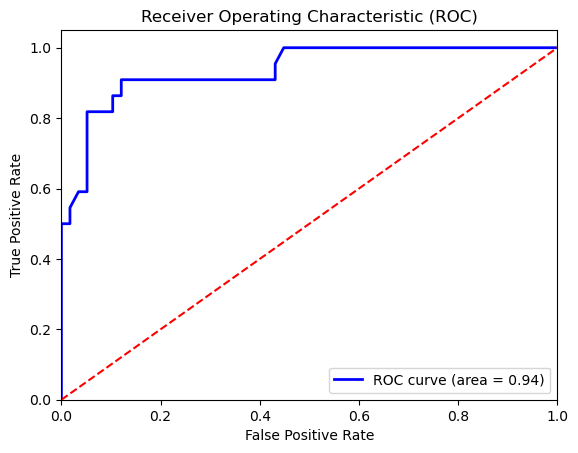

In [99]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
#modelin performansını daha iyi görmek için ROC eğrisi çiziyorum.
y_prob = model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob, pos_label=1) 
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='lower right')
plt.show()

In [2]:
#lojistik regresyon
#desiciontree
#svm svc
#knn
#tensorflow
#lstm


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

models = [
    ("Decision Tree", DecisionTreeClassifier()),
    ("Random Forest", RandomForestClassifier()),
    ("Logistic Regression", LogisticRegression(max_iter=200)),
    ("Support Vector Machine", SVC()),
    ("K-Nearest Neighbors", KNeighborsClassifier()),
    ("Naive Bayes", GaussianNB())
]

for model_name, model in models:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    
    print(f"Performance Metrics for {model_name}:")
    print(f"Confusion Matrix:\n{cm}")
    print(f"Accuracy Score: {acc:.2f}")
    print(f"Classification Report:\n{report}")
    print("\n")